In [6]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [7]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image

import pandas as pd
import numpy as nn
import torch.nn as nn
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [8]:
train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
train_df.head()

val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")
train_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + val_df["image:FILE"]



In [9]:
val_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/val/...,0
1,/content/bean-leaf-lesions-classification/val/...,0
2,/content/bean-leaf-lesions-classification/val/...,0
3,/content/bean-leaf-lesions-classification/val/...,0
4,/content/bean-leaf-lesions-classification/val/...,0


In [10]:
train_df["category"].unique()

array([0, 1, 2])

In [11]:
val_df["category"].unique

<bound method Series.unique of 0      0
1      0
2      0
3      0
4      0
      ..
128    2
129    2
130    2
131    2
132    2
Name: category, Length: 133, dtype: int64>

In [12]:
print(train_df.shape)
print(val_df.shape)

(1034, 2)
(133, 2)


In [13]:
print(train_df["category"].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [14]:
transform = transforms.Compose([
    transforms.Resize((132, 132)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])

In [15]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe["category"]).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = (self.transform(image)/255.0).to(device)

    return image, label





In [16]:
train_dataset = CustomImageDataset(dataframe = train_df, transform = transform)
val_dataset = CustomImageDataset(dataframe = val_df, transform = transform)

In [17]:
import numpy as np

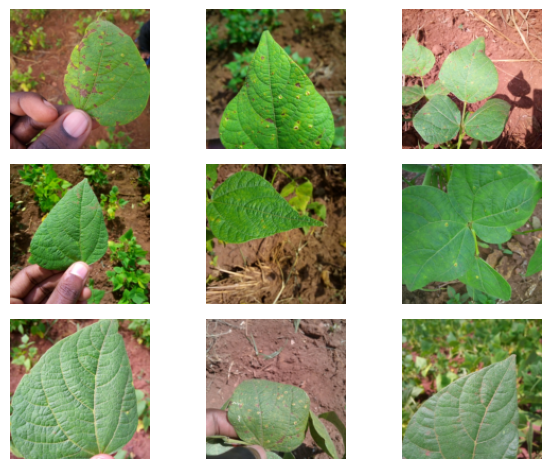

In [18]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow((image * 255.0).squeeze().permute(1, 2, 0))
    axarr[row, col].axis('off')

plt.tight_layout()
plt.show()


In [19]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 15

In [20]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [21]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 123MB/s]


In [22]:
for param in googlenet_model.parameters():
  param.requires_grad = True


In [23]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [24]:
num_classes = len(train_df["category"].unique())
num_classes

3

In [25]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [ ]:
googlenet_model.to(device)

In [27]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 6))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 6))

  print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 6)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 6)} %")





Epoch 1/15, Train Loss: 0.232939, Train Accuracy: 58.220503 %
Epoch 2/15, Train Loss: 0.202213, Train Accuracy: 67.794971 %
Epoch 3/15, Train Loss: 0.17941, Train Accuracy: 71.663443 %
Epoch 4/15, Train Loss: 0.180429, Train Accuracy: 71.083172 %
Epoch 5/15, Train Loss: 0.169148, Train Accuracy: 72.727273 %
Epoch 6/15, Train Loss: 0.144699, Train Accuracy: 79.110251 %
Epoch 7/15, Train Loss: 0.141332, Train Accuracy: 79.787234 %
Epoch 8/15, Train Loss: 0.118532, Train Accuracy: 82.978723 %
Epoch 9/15, Train Loss: 0.098333, Train Accuracy: 85.589942 %
Epoch 10/15, Train Loss: 0.108704, Train Accuracy: 84.622824 %
Epoch 11/15, Train Loss: 0.099686, Train Accuracy: 85.396518 %
Epoch 12/15, Train Loss: 0.102372, Train Accuracy: 85.299807 %
Epoch 13/15, Train Loss: 0.087, Train Accuracy: 87.62089 %
Epoch 14/15, Train Loss: 0.073417, Train Accuracy: 90.135397 %
Epoch 15/15, Train Loss: 0.080968, Train Accuracy: 88.104449 %


In [29]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for input, labels in val_loader:
    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

In [30]:
print(round(total_acc_test/val_dataset.__len__() * 100, 4))

87.218


# Transfer Learning

In [ ]:
googlenet_model = models.googlenet(weights = 'DEFAULT')

for param in googlenet_model.parameters():
  param.requires_grad = False

googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc.requires_grad = True
googlenet_model.to(device)


In [35]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr = LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = loss_fun(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 6))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__() * 100, 6))

  print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {round(total_loss_train/1000, 6)}, Train Accuracy: {round(total_acc_train/train_dataset.__len__() * 100, 6)} %")





Epoch 1/15, Train Loss: 0.274578, Train Accuracy: 45.647969 %
Epoch 2/15, Train Loss: 0.243254, Train Accuracy: 55.222437 %
Epoch 3/15, Train Loss: 0.241967, Train Accuracy: 56.96325 %
Epoch 4/15, Train Loss: 0.229339, Train Accuracy: 58.994197 %
Epoch 5/15, Train Loss: 0.234648, Train Accuracy: 58.994197 %
Epoch 6/15, Train Loss: 0.227281, Train Accuracy: 61.218569 %
Epoch 7/15, Train Loss: 0.222967, Train Accuracy: 60.154739 %
Epoch 8/15, Train Loss: 0.222763, Train Accuracy: 60.638298 %
Epoch 9/15, Train Loss: 0.211451, Train Accuracy: 63.829787 %
Epoch 10/15, Train Loss: 0.221175, Train Accuracy: 61.218569 %
Epoch 11/15, Train Loss: 0.216959, Train Accuracy: 62.37911 %
Epoch 12/15, Train Loss: 0.218191, Train Accuracy: 62.475822 %
Epoch 13/15, Train Loss: 0.220974, Train Accuracy: 61.508704 %
Epoch 14/15, Train Loss: 0.225258, Train Accuracy: 62.37911 %
Epoch 15/15, Train Loss: 0.217962, Train Accuracy: 61.798839 %


In [36]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for input, labels in val_loader:
    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

In [37]:
print(round(total_acc_test/val_dataset.__len__() * 100, 4))

57.8947


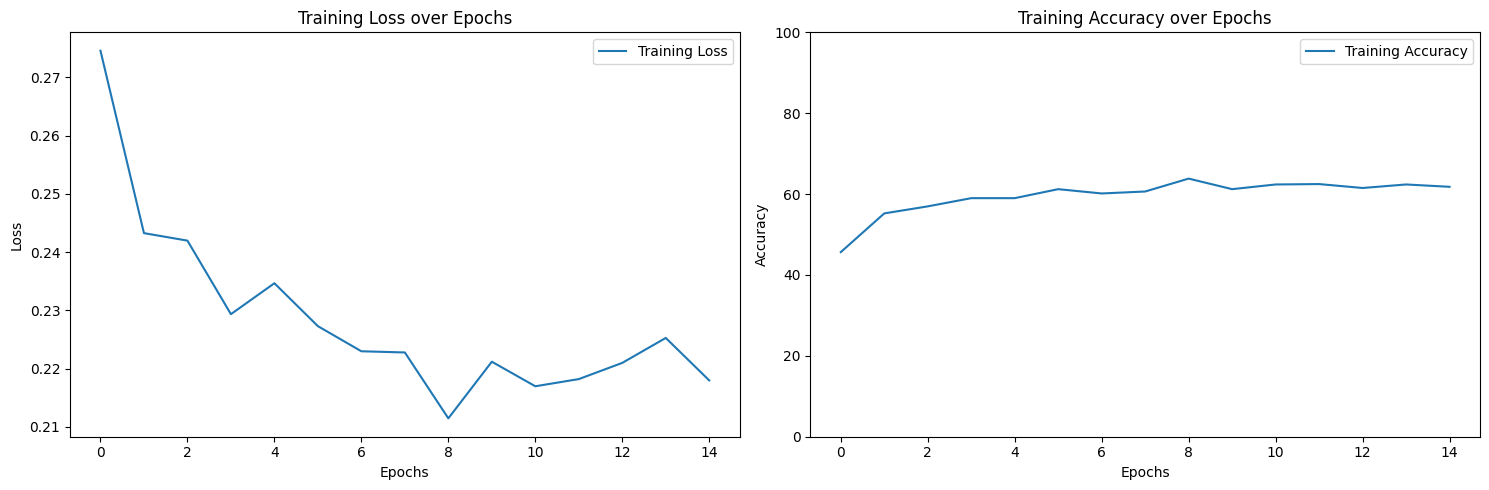

In [40]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].set_title('Training Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].set_title('Training Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()